# Notebook 3 — Multimodal Inference

Author: Eun-Kyeong Kim (eun-kyeong.kim@lxp.lu), LuxProvide S.A

## Multimodal Flood Detection with TerraMind on MeluXina HPC

**Goal:** Load the pre-trained TerraMind foundation model, run it on the packaged
multi-modal satellite chips prepared in Notebook 2, and visualise the predicted
flood / water masks alongside the input imagery.

### What you will learn
- How to load a PyTorch Lightning checkpoint for inference-only mode
- How to structure multi-modal tensor inputs for TerraMind (`S2L2A`, `S1RTC`, `DEM`)
- How to interpret binary segmentation outputs from a foundation model
- How to read SAR imagery correctly (decibel scale, percentile stretching)

### Prerequisites
- Notebook 2 must have completed and written its output files to disk.
- A **GPU** node must be allocated (check with `nvidia-smi`).

---


### 1 · Environment setup and imports

> **Why reset `sys.argv`?**
> PyTorch Lightning parses command-line arguments at import time.
> When running inside JupyterLab, Jupyter injects internal flags (e.g. `-f /run/...`)
> that crash Lightning's argument parser.
> Resetting `sys.argv` to a single-element list removes those flags **before**
> importing Lightning, so the import succeeds without errors.


In [1]:
import sys

sys.argv = [sys.argv[0]]

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from terratorch.tasks import SemanticSegmentationTask
from huggingface_hub import hf_hub_download

import warnings
warnings.filterwarnings('ignore')

### 2 · Configuration

Adjust the paths below if your files live elsewhere.
Everything else is derived from what Notebook 2 saved.


In [2]:
# ── Model checkpoint ─────────────────────────────────────────────────────
# Place the downloaded checkpoint file at this path before running.
MODEL_PATH = "models/TerraMind_v1_base_ImpactMesh_flood.pt"

# ── Data paths (must match Notebook 2 outputs) ────────────────────────────
CHIP_CSV  = "./data/terramind_flood_lux/package/chip_manifest_multimodal.csv"
S1RTC_NPY = "./data/terramind_flood_lux/package/full_scene/S1RTC_full.npy"
S2L2A_NPY = "./data/terramind_flood_lux/package/full_scene/S2L2A_full.npy"
DEM_NPY   = "./data/terramind_flood_lux/package/full_scene/DEM_full.npy"
LABEL_NPY = "./data/terramind_flood_lux/package/full_scene/luxembourg_label_max_flood.npy"

# ── Inference settings ────────────────────────────────────────────────────
# Number of water-rich chips to visualise (higher → longer runtime)
N_CHIPS_TO_SHOW    = 5
# Minimum water fraction required for a chip to be selected for display
MIN_WATER_FRACTION = 0.0   # show all water-containing chips if 0

### 3 · Acquire and load the TerraMind model

#### Downloading the TerraMind flood impact model
This script below downloads the TerraMind flood impact model (`.pt` file) directly from a public Hugging Face repository and saves it to a local directory. It ensures the target path exists and uses Python’s standard library for a simple, reliable download without additional dependencies.

In [3]:
hf_hub_download(
    repo_id="ibm-esa-geospatial/TerraMind-base-Flood",
    filename="TerraMind_v1_base_ImpactMesh_flood.pt",
    local_dir="models",
)

2026-04-28 16:22:50,104 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-base-Flood/resolve/main/TerraMind_v1_base_ImpactMesh_flood.pt "HTTP/1.1 302 Found"


'models/TerraMind_v1_base_ImpactMesh_flood.pt'

#### Loading the TerraMind flood impact model
`SemanticSegmentationTask` is a PyTorch Lightning wrapper around the TerraMind
encoder + segmentation head. We load it from a checkpoint (`.pt` file) and
immediately switch to evaluation mode.

- `load_from_checkpoint(..., strict=False)` — ignores checkpoint keys that do not
  match the current model definition (e.g., saved logger settings from training).
- `.cuda()` — moves the model to GPU memory.
- `.eval()` — disables dropout and batch-normalisation updates.

In [4]:
print("Loading TerraMind model from checkpoint...")
try:
    # strict=False tolerates minor mismatches between the saved checkpoint
    # and the installed terratorch version (e.g., extra logger config keys).
    task  = SemanticSegmentationTask.load_from_checkpoint(MODEL_PATH, strict=True)
    model = task.model.cuda().eval()
    print("Model ready on GPU.")
except Exception as err:
    print(f"ERROR: Could not load checkpoint.\n  {err}")
    raise

Loading TerraMind model from checkpoint...


2026-04-28 16:22:56,592 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"


Model ready on GPU.


### 4 · Load the packaged satellite data

We memory-map the `.npy` arrays — this means the files are **not** fully loaded
into RAM immediately.  Only the pixel windows we actually slice will be read from
disk during inference, keeping memory use low.

Array shapes (from Notebook 2):
```
s1rtc  : (2,  4, H, W)   — S1 [VV, VH] over 4 temporal phases
s2l2a  : (12, 4, H, W)   — S2 12 bands over 4 temporal phases
dem    : (1,     H, W)   — elevation (static)
label  : (H, W)          — reference water/flood mask
```


In [5]:
chip_df = pd.read_csv(CHIP_CSV)
s1rtc   = np.load(S1RTC_NPY, mmap_mode="r")
s2l2a   = np.load(S2L2A_NPY, mmap_mode="r")
dem     = np.load(DEM_NPY,   mmap_mode="r")
label   = np.load(LABEL_NPY)

print(f"Chip index  : {len(chip_df)} chips")
print(f"S1RTC shape : {s1rtc.shape}   (bands, time-steps, H, W)")
print(f"S2L2A shape : {s2l2a.shape}   (bands, time-steps, H, W)")
print(f"DEM shape   : {dem.shape}   (1 channel, H, W)")
print(f"Label shape : {label.shape}")

Chip index  : 890 chips
S1RTC shape : (2, 4, 8449, 6033)   (bands, time-steps, H, W)
S2L2A shape : (12, 4, 8449, 6033)   (bands, time-steps, H, W)
DEM shape   : (1, 8449, 6033)   (1 channel, H, W)
Label shape : (8449, 6033)


### 5 · Select chips with the most water

We use the reference flood label to rank chips by the fraction of water pixels
they contain. Selecting the most water-rich chips lets us evaluate whether the
model correctly identifies flooded areas — the most scientifically interesting
locations to examine.

> **Note:** The reference label includes both *permanent* water bodies (rivers,
> lakes) and *event* flood water. We use it here solely as a spatial guide to
> find interesting chips — not as a strict accuracy benchmark for "flood-only"
> detection.


In [6]:
def compute_water_fraction(row: pd.Series) -> float:
    """Return the fraction of pixels labelled as water in a chip.

    A value of 0.0 means the chip is entirely land; 1.0 means entirely water.
    """
    r0, r1, c0, c1 = row["row0"], row["row1"], row["col0"], row["col1"]
    chip_label = label[r0:r1, c0:c1]
    return float((chip_label == 1).mean())


print("Computing water fractions for all chips...")
chip_df["water_fraction"] = chip_df.apply(compute_water_fraction, axis=1)

# Keep only chips that contain some water; rank by water fraction (highest first)
water_chips = (
    chip_df[chip_df["water_fraction"] > MIN_WATER_FRACTION]
    .sort_values("water_fraction", ascending=False)
    .head(N_CHIPS_TO_SHOW)
)

print(f"Selected {len(water_chips)} chip(s) for inference and visualisation.")
water_chips[["chip_id", "row0", "col0", "chip_valid_fraction", "water_fraction"]]

Computing water fractions for all chips...
Selected 5 chip(s) for inference and visualisation.


,chip_id,row0,col0,chip_valid_fraction,water_fraction
577,lux_04784_02704,4784,2704,1.0,0.333755
863,lux_07072_02912,7072,2912,1.0,0.332062
656,lux_05408_02912,5408,2912,1.0,0.305328
838,lux_06864_02912,6864,2912,1.0,0.304749
603,lux_04992_02704,4992,2704,1.0,0.287750


### 6 · Multimodal inference function

This function performs one forward pass of TerraMind on a single chip.

#### Tensor layout

TerraMind expects every modality as a **5-D tensor**:
`[Batch, Channels, Time, Height, Width]`

| Modality | Channels | Time steps | Tensor shape |
|---|---|---|---|
| S2 optical | 12 | 4 | `[1, 12, 4, 256, 256]` |
| S1 SAR | 2 | 4 | `[1, 2, 4, 256, 256]` |
| DEM elevation | 1 | 4* | `[1, 1, 4, 256, 256]` |

*\* DEM is static — it has no real time axis. We repeat it 4× along the time
dimension so the model receives a consistent 5-D tensor for all modalities.

#### Why `torch.no_grad()`?

During training, PyTorch records gradients for every operation. At inference time
we do not need gradients, so `torch.no_grad()` skips that bookkeeping — making
inference faster and using ~half the GPU memory.


In [7]:
def run_inference_on_chip(row: pd.Series):
    """Slice chip from global arrays, run TerraMind, return results for plotting.

    Parameters
    ----------
    row : one row from the chip manifest DataFrame

    Returns
    -------
    s2_rgb   : (3, 256, 256)  float32  — S2 true-colour bands for visualisation
    s1_vv    : (256, 256)     float32  — S1 VV backscatter (linear scale)
    dem_chip : (256, 256)     float32  — elevation
    ref_chip : (256, 256)     uint8    — reference water label
    pred     : (256, 256)     int      — model prediction (1=water, 0=land)
    """
    r0, r1, c0, c1 = row["row0"], row["row1"], row["col0"], row["col1"]

    # ── Slice chips from memory-mapped arrays ─────────────────────────────
    # Arrays are (C, T, H, W); slicing H and W gives (C, T, chip_H, chip_W)

    # S2 optical: [C=12, T=4, 256, 256] → add batch dim → [1, 12, 4, 256, 256]
    s2_tensor = (torch.from_numpy(s2l2a[:, :, r0:r1, c0:c1].copy())
                 .float().unsqueeze(0).cuda())

    # S1 SAR:     [C=2, T=4, 256, 256] → add batch dim → [1, 2, 4, 256, 256]
    s1_tensor = (torch.from_numpy(s1rtc[:, :, r0:r1, c0:c1].copy())
                 .float().unsqueeze(0).cuda())

    # DEM:        [C=1, 256, 256]
    #   → unsqueeze(0)  → [1, 1, 256, 256]
    #   → unsqueeze(2)  → [1, 1, 1, 256, 256]   (insert time axis)
    #   → repeat(...)   → [1, 1, 4, 256, 256]   (replicate across time)
    dem_tensor = (torch.from_numpy(dem[:, r0:r1, c0:c1].copy())
                  .float().unsqueeze(0).unsqueeze(2)
                  .repeat(1, 1, 4, 1, 1).cuda())

    # ── Forward pass ─────────────────────────────────────────────────────
    multimodal_input = {"S2L2A": s2_tensor, "S1RTC": s1_tensor, "DEM": dem_tensor}

    with torch.no_grad():
        model_output = model(multimodal_input)

        # The model returns a named output object; extract the logits tensor.
        # Shape: [1, num_classes, H, W]  (num_classes = 2: land vs water)
        logits = model_output.output if hasattr(model_output, "output") else model_output

        # Argmax over the class dimension → binary mask: 1 = water, 0 = land
        # Shape: [256, 256] as a NumPy array
        pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

    # ── Extract visualisation layers ──────────────────────────────────────
    # S2 true-colour: bands B04/B03/B02 (indices 3, 2, 1) at time-step 0
    s2_rgb   = s2_tensor[0, [3, 2, 1], 0].cpu().numpy()   # (3, 256, 256)
    # S1 VV at time-step 0 (linear scale — convert to dB for display later)
    s1_vv    = s1_tensor[0, 0, 0].cpu().numpy()            # (256, 256)
    # DEM and reference label (already NumPy; slice directly)
    dem_chip = dem[0, r0:r1, c0:c1]                        # (256, 256)
    ref_chip = label[r0:r1, c0:c1]                         # (256, 256)

    return s2_rgb, s1_vv, dem_chip, ref_chip, pred_mask

### 7 · Run inference and visualise results

For each selected chip we display five panels:

| Panel | Description |
|---|---|
| **S2 RGB** | True-colour composite (bands B04/B03/B02). Cloud-free, natural colours. |
| **S1 VV (dB)** | SAR backscatter in decibels. Water = very dark (specular reflection). |
| **DEM** | Terrain elevation — low-lying areas near rivers are flood-prone. |
| **Reference label** | Copernicus EMS flood extent (blue = water). Ground truth proxy. |
| **TerraMind prediction** | Model output (blue = predicted water). Compare with the reference. |

> **SAR visualisation tip:** SAR images contain extremely bright outliers
> (metal roofs, corner reflectors). Displaying the raw values makes the image
> look entirely black. We apply *percentile stretching* — clipping at the
> 2nd and 98th percentiles — to reveal the terrain texture and make specular
> reflectors (water) visible as dark patches.


Running TerraMind inference on 5 chip(s)...



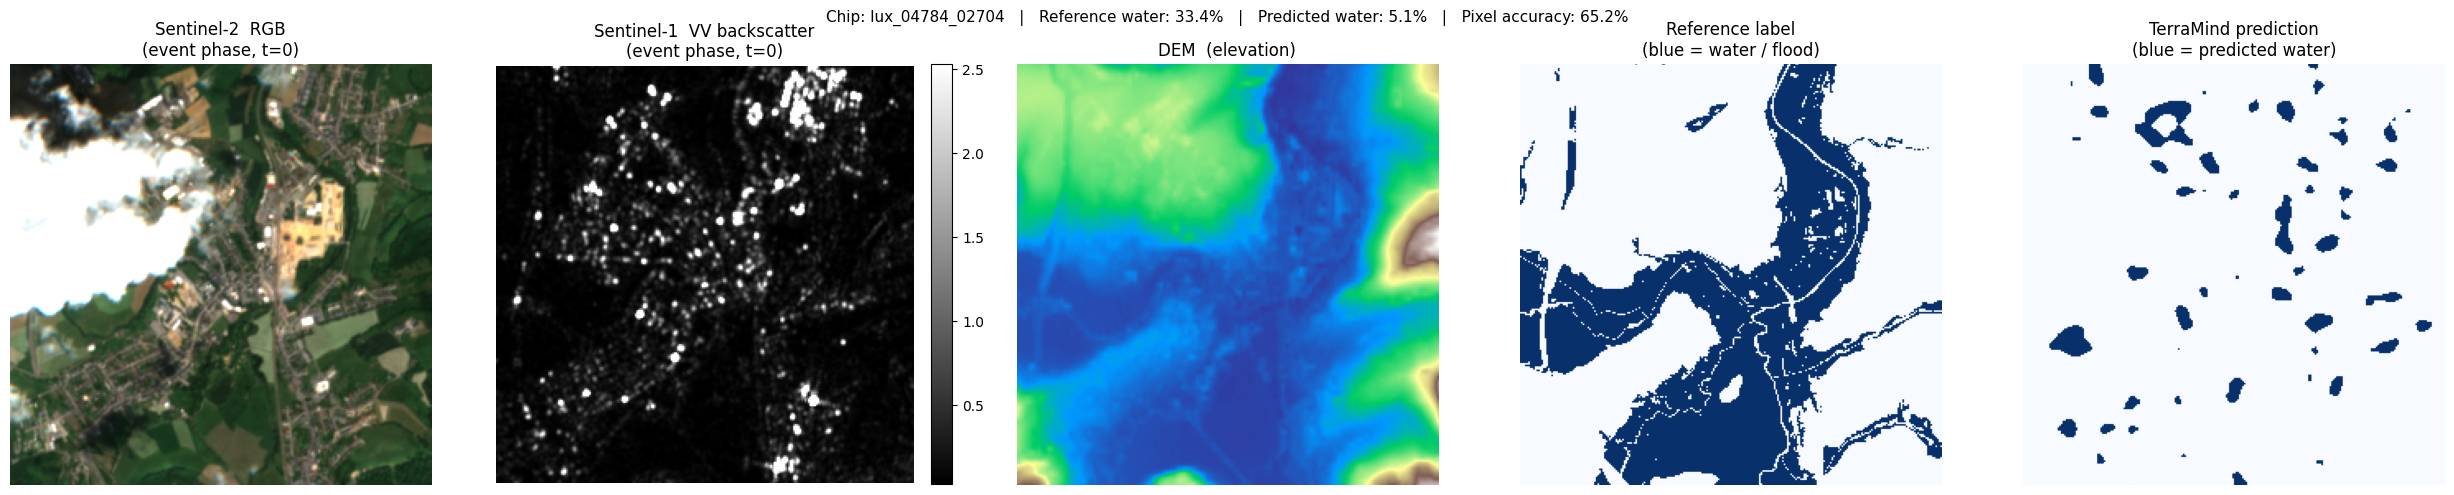

  lux_04784_02704: ref 33.4% water  →  pred 5.1%  (accuracy 65.2%)



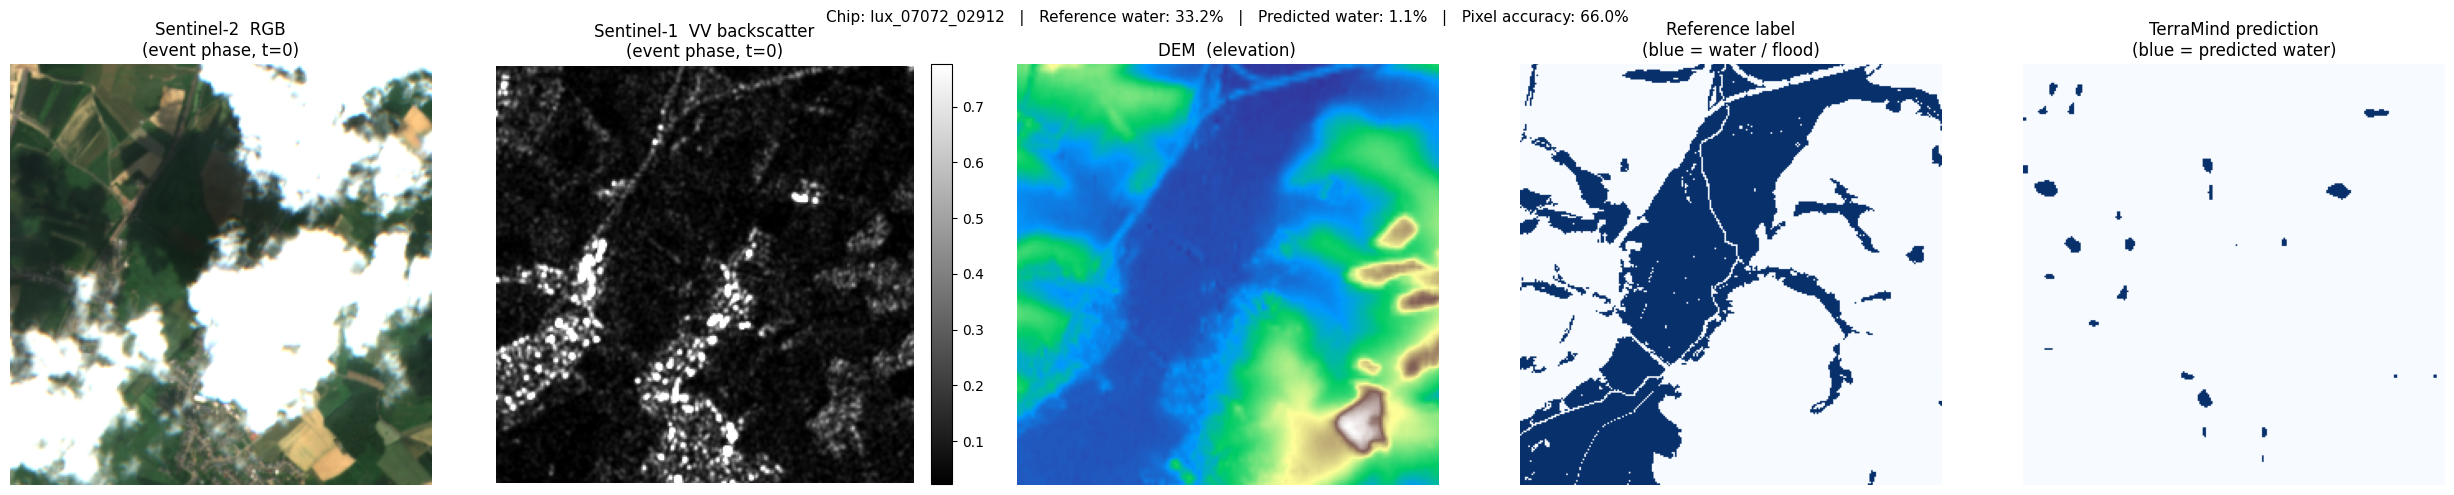

  lux_07072_02912: ref 33.2% water  →  pred 1.1%  (accuracy 66.0%)



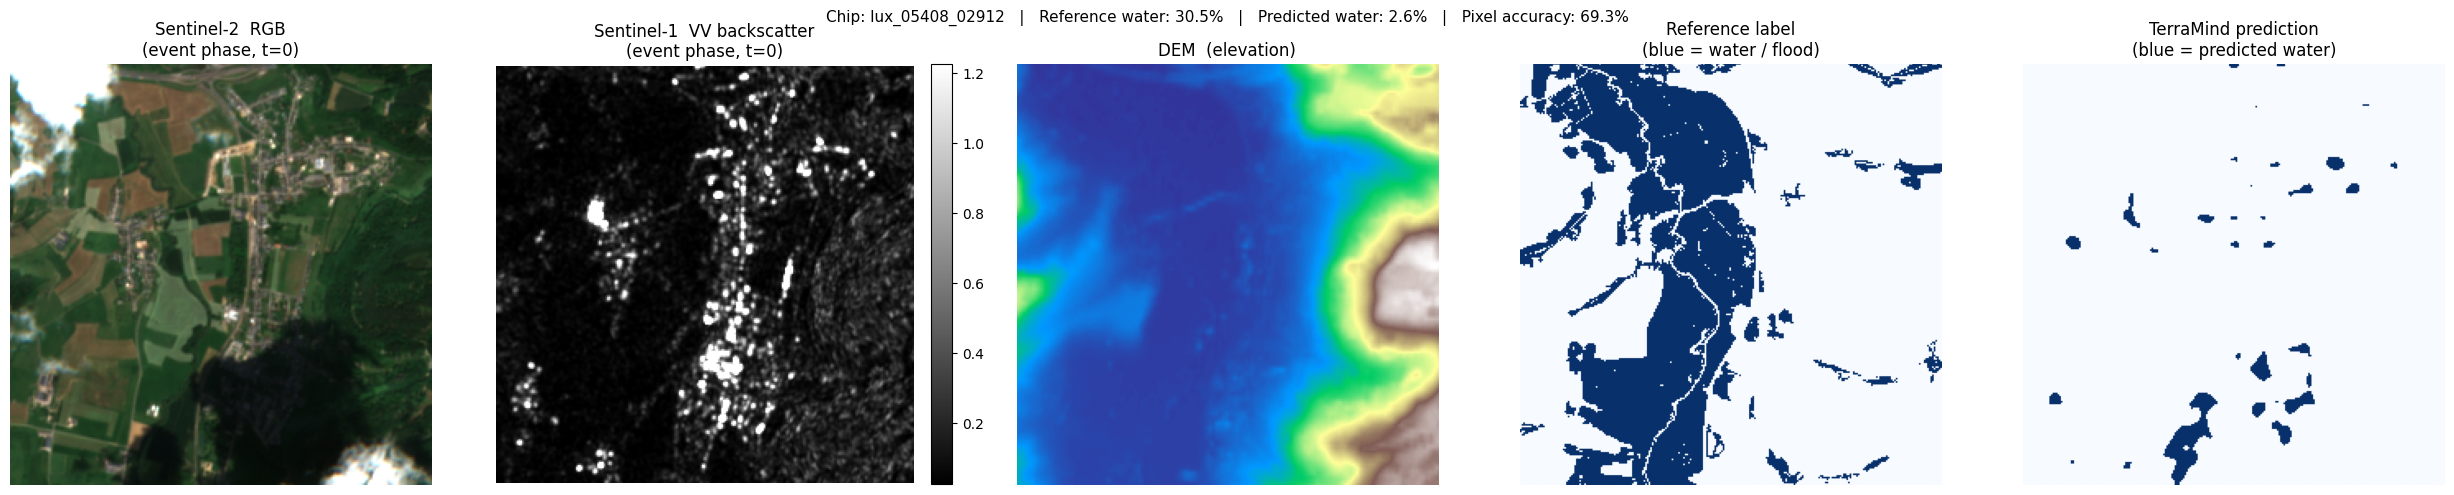

  lux_05408_02912: ref 30.5% water  →  pred 2.6%  (accuracy 69.3%)



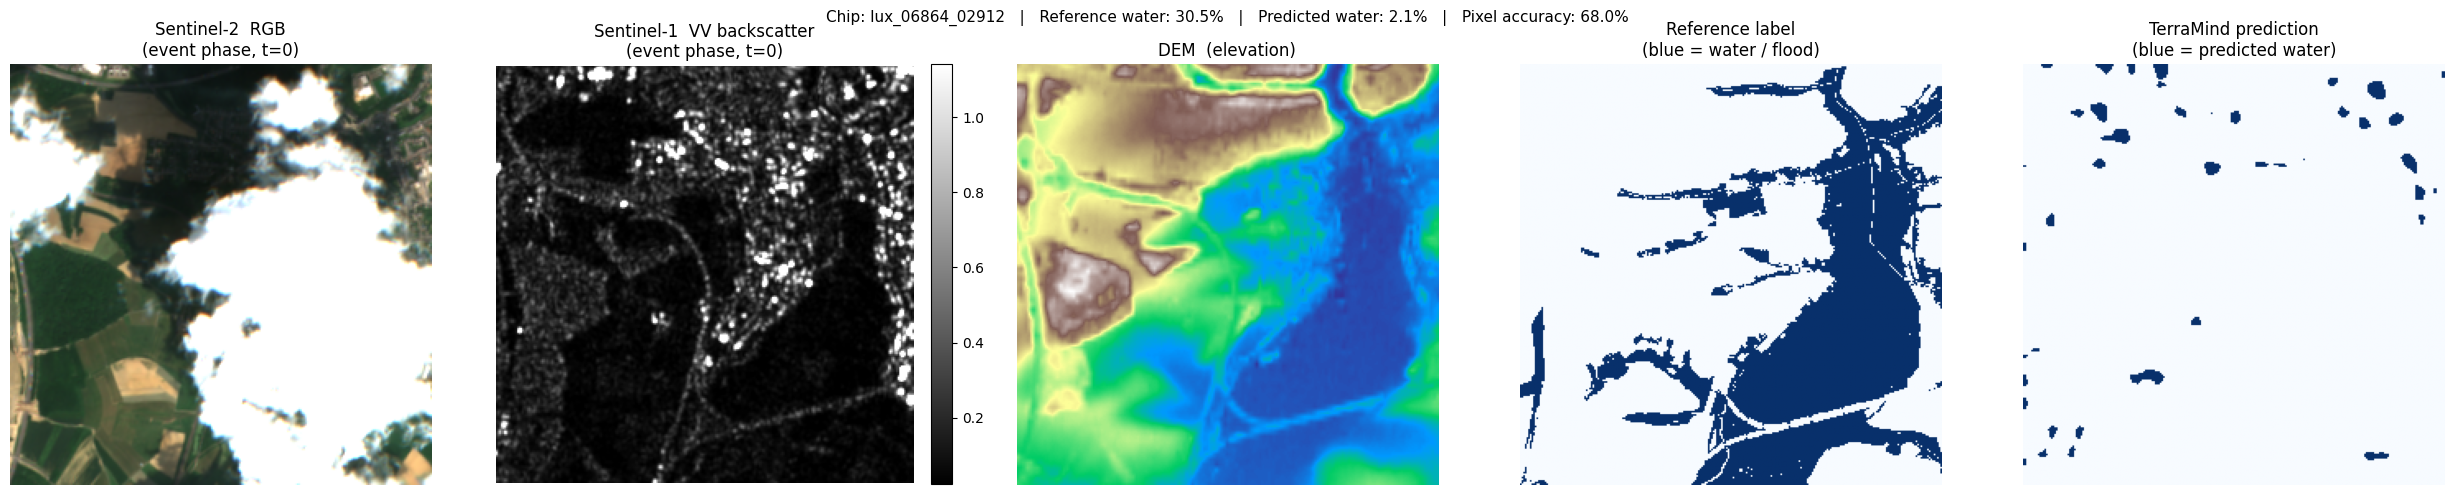

  lux_06864_02912: ref 30.5% water  →  pred 2.1%  (accuracy 68.0%)



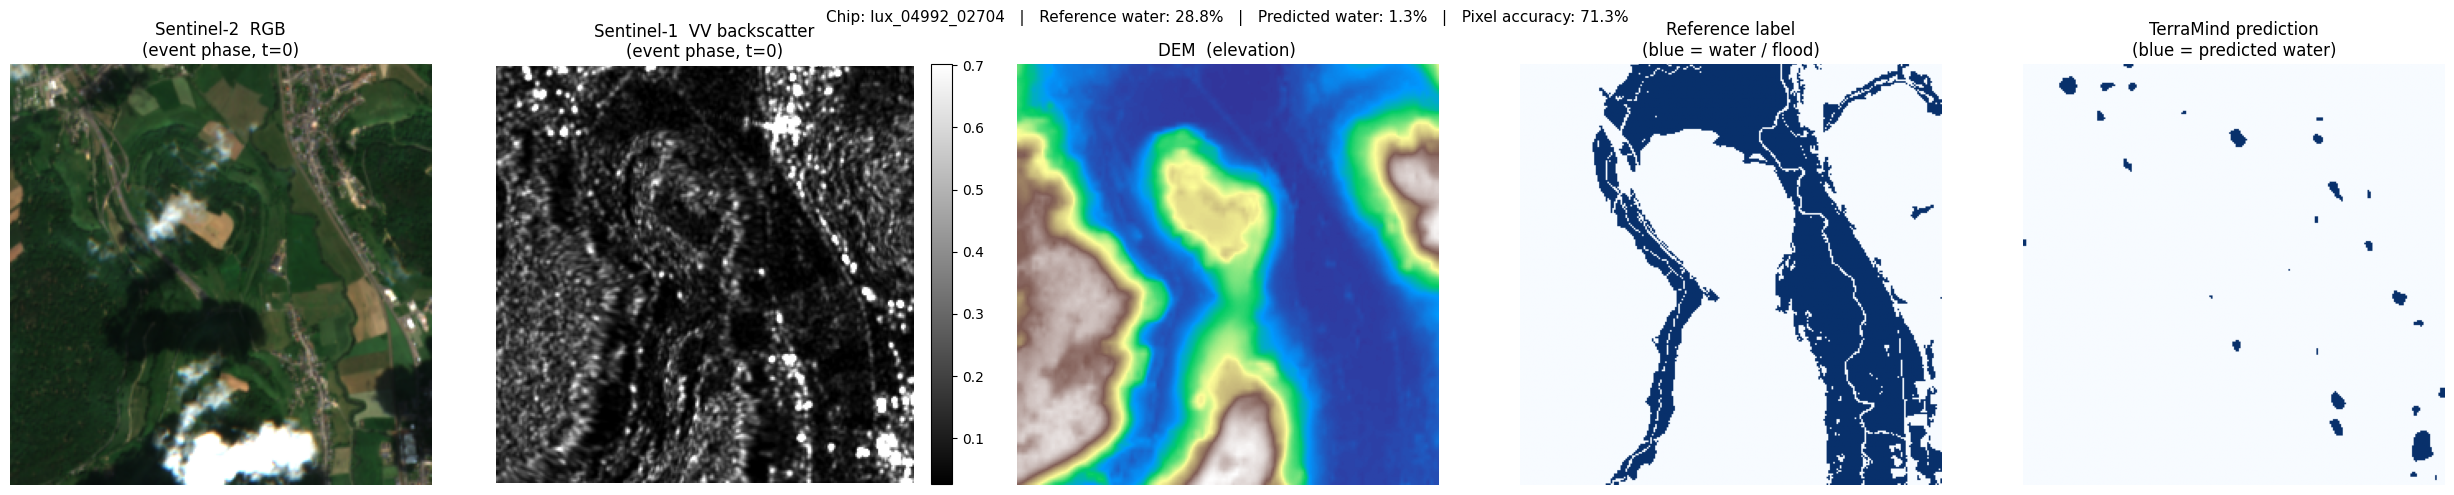

  lux_04992_02704: ref 28.8% water  →  pred 1.3%  (accuracy 71.3%)



In [8]:
print(f"Running TerraMind inference on {len(water_chips)} chip(s)...\n")

for _, chip_row in water_chips.iterrows():
    chip_id = chip_row["chip_id"]
    water_pct = chip_row["water_fraction"] * 100

    s2_rgb, s1_vv, dem_chip, ref_chip, pred_mask = run_inference_on_chip(chip_row)

    # ── Prepare S2 display: divide by 3000 to approximate surface reflectance
    s2_display = np.clip(s2_rgb.transpose(1, 2, 0) / 3000, 0, 1)

    # ── Prepare S1 display: percentile-stretch to handle bright scatterers
    vv_lo, vv_hi = np.percentile(s1_vv, 2), np.percentile(s1_vv, 98)

    # ── Compute simple accuracy metrics for this chip ─────────────────────
    # (pixel-level agreement between reference label and prediction)
    valid_px     = (ref_chip >= 0)          # all pixels are labelled here
    accuracy     = float((pred_mask[valid_px] == ref_chip[valid_px]).mean())
    pred_water   = float(pred_mask.mean())
    ref_water    = float(ref_chip.mean())

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(
        f"Chip: {chip_id}   |   Reference water: {water_pct:.1f}%   |   "
        f"Predicted water: {pred_water*100:.1f}%   |   Pixel accuracy: {accuracy*100:.1f}%",
        fontsize=11,
    )

    # Panel 1 — S2 RGB
    axes[0].imshow(s2_display)
    axes[0].set_title("Sentinel-2  RGB\n(event phase, t=0)")
    axes[0].axis("off")

    # Panel 2 — S1 VV in dB (percentile-stretched)
    im_s1 = axes[1].imshow(s1_vv, cmap="gray", vmin=vv_lo, vmax=vv_hi)
    axes[1].set_title("Sentinel-1  VV backscatter\n(event phase, t=0)")
    axes[1].axis("off")
    plt.colorbar(im_s1, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel 3 — DEM
    axes[2].imshow(dem_chip, cmap="terrain")
    axes[2].set_title("DEM  (elevation)")
    axes[2].axis("off")

    # Panel 4 — Reference label
    axes[3].imshow(ref_chip, cmap="Blues", vmin=0, vmax=1)
    axes[3].set_title("Reference label\n(blue = water / flood)")
    axes[3].axis("off")

    # Panel 5 — TerraMind prediction
    axes[4].imshow(pred_mask, cmap="Blues", vmin=0, vmax=1)
    axes[4].set_title("TerraMind prediction\n(blue = predicted water)")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()
    print(f"  {chip_id}: ref {ref_water*100:.1f}% water  →  pred {pred_water*100:.1f}%  "
          f"(accuracy {accuracy*100:.1f}%)\n")